In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
%matplotlib inline

I0000 00:00:1779838421.863918   19420 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779838422.069273   19420 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779838427.560299   19420 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df_test = pd.read_csv("dataset/teen_test_clean.csv")
df_test.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,1.490790,-0.513854,-1.077065,-1.729166,1.201832,1.283458,0.882057,-0.545846,-0.904702,0,1,0,3.68
1,-0.469701,0.963386,-0.731297,0.497713,1.374035,-1.195656,0.540753,-0.896825,0.149746,1,0,1,3.44
2,1.000667,-1.055508,-0.108917,-0.615726,1.201832,-1.195656,-1.165766,1.209050,-0.201737,0,1,0,3.05


In [3]:
df_train = pd.read_csv("dataset/teen_train_clean.csv")
df_train.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,0.020422,0.766421,1.135845,-0.476546,1.029629,-1.195656,1.564665,-1.598783,-0.553219,0,1,0,3.27
1,-0.469701,0.569455,0.720924,0.915253,0.513021,0.043901,1.564665,1.560029,-1.256185,0,1,0,2.84
2,-1.449946,-1.695645,0.444311,0.080173,-0.347993,1.283458,-0.141854,-0.194867,1.555678,1,0,1,2.55


In [4]:
y_test = df_test['target_academic_performance']
df_test = df_test.drop(columns=['target_academic_performance'])
X_test = df_test.copy()
y_test.head()

0    3.68
1    3.44
2    3.05
3    3.56
4    2.16
Name: target_academic_performance, dtype: float64

In [5]:
X_test.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,1.490790,-0.513854,-1.077065,-1.729166,1.201832,1.283458,0.882057,-0.545846,-0.904702,0,1,0
1,-0.469701,0.963386,-0.731297,0.497713,1.374035,-1.195656,0.540753,-0.896825,0.149746,1,0,1
2,1.000667,-1.055508,-0.108917,-0.615726,1.201832,-1.195656,-1.165766,1.209050,-0.201737,0,1,0
3,-1.449946,-1.055508,-0.662144,-1.589986,1.029629,0.043901,-0.483158,0.858071,0.501229,0,1,0
4,-1.449946,1.357317,-1.561139,-0.615726,-0.003588,1.283458,-0.483158,-0.194867,-1.256185,1,0,0


In [6]:
y_train = df_train['target_academic_performance']
df_train = df_train.drop(columns=['target_academic_performance'])
X_train = df_train.copy()
y_train.head()

0    3.27
1    2.84
2    2.55
3    2.54
4    3.81
Name: target_academic_performance, dtype: float64

In [7]:
X_train.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,0.020422,0.766421,1.135845,-0.476546,1.029629,-1.195656,1.564665,-1.598783,-0.553219,0,1,0
1,-0.469701,0.569455,0.720924,0.915253,0.513021,0.043901,1.564665,1.560029,-1.256185,0,1,0
2,-1.449946,-1.695645,0.444311,0.080173,-0.347993,1.283458,-0.141854,-0.194867,1.555678,1,0,1
3,0.020422,0.372490,-1.491985,-0.337366,-1.209007,1.283458,0.540753,0.507092,1.555678,0,0,1
4,-0.959824,0.914145,-0.316377,-0.894086,-0.175790,0.043901,0.882057,-1.247804,-0.904702,0,1,0


In [8]:
BATCH_SIZE = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train.to_numpy(), y_train.to_numpy()))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.to_numpy(), y_test.to_numpy()))


E0000 00:00:1779838434.191655   19420 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
input_shape_dim = X_train.shape[1]
model = Sequential([
    # Input Layer matching your preprocessed feature columns
    Input(shape=(input_shape_dim,)),
    
    # Dense Hidden Layer 1: 64 neurons capturing initial non-linear feature interactions
    Dense(64, activation='relu'),
    Dropout(0.2),  # Prevents overfitting by randomly deactivating neurons during training
    
    # Dense Hidden Layer 2: 32 neurons refining learned abstractions
    Dense(32, activation='relu'),
    
    # Output Layer: 1 single neuron with NO activation function (Linear Output)
    # Crucial for regression tasks predicting an open continuous number
    Dense(1)
])

# View a clean structural printout of your layer dimensions and parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',             # Adaptive Moment Estimation (robust, self-adjusting learning rate)
    loss='mse',                   # Loss function minimized by Gradient Descent
    metrics=['mae', 'root_mean_squared_error']       # Evaluation tracking metrics
)

In [18]:
history = model.fit(
    train_dataset.shuffle(buffer_size=len(X_train)).batch(BATCH_SIZE),
    epochs=40,
    verbose=1
)

Epoch 1/40
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3349 - mae: 0.5300 - root_mean_squared_error: 0.5787

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3309 - mae: 0.4821 - root_mean_squared_error: 0.5753
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3241 - mae: 0.4752 - root_mean_squared_error: 0.5693
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3522 - mae: 0.4995 - root_mean_squared_error: 0.5934
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3299 - mae: 0.4824 - root_mean_squared_error: 0.5744
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3206 - mae: 0.4737 - root_mean_squared_error: 0.5662
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3185 - mae: 0.4711 - root_mean_squared_error: 0.5644
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3014 - mae: 0.4621 - root_mean_squared_error: 0.5490
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3273 - mae: 0.4772 - root_mean_squared_error: 0.5721
Epoch 9/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3178 - mae: 0.4756 - root_mean_squared_error: 0

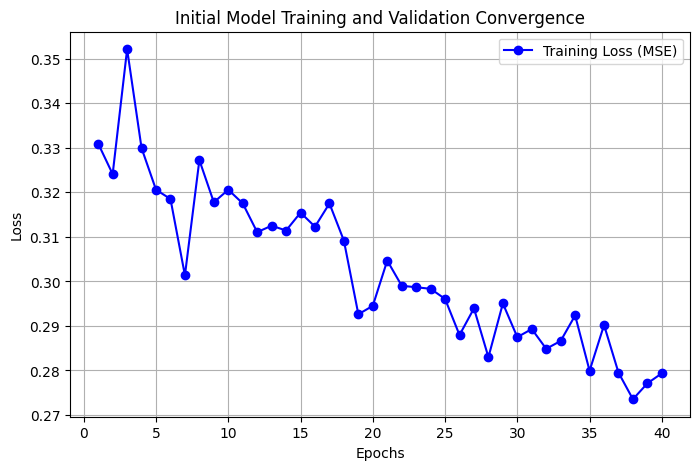

In [20]:
# Extract metrics from history logs
train_loss = history.history['loss']
epochs = range(1, len(train_loss) + 1)

# Generate Loss Convergence Curve
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'bo-', label='Training Loss (MSE)')
plt.title('Initial Model Training and Validation Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
model.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3783 - mae: 0.5130 - root_mean_squared_error: 0.6151


[0.3782959580421448, 0.5130342841148376, 0.6150577068328857]